# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [17]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [18]:
# Add as many cells as you need
df = pd.read_csv("zillow_cleaned.csv")
df.head


<bound method NDFrame.head of        bathroomcnt  bedroomcnt  buildingqualitytypeid  calculatedbathnbr  \
0              3.5         4.0                    6.0                3.5   
1              1.0         2.0                    6.0                1.0   
2              2.0         3.0                    6.0                2.0   
3              3.0         4.0                    8.0                3.0   
4              3.0         3.0                    8.0                3.0   
...            ...         ...                    ...                ...   
77104          3.0         3.0                    8.0                3.0   
77105          2.0         2.0                    6.0                2.0   
77106          2.0         4.0                    6.0                2.0   
77107          1.0         3.0                    4.0                1.0   
77108          2.0         3.0                    6.0                2.0   

       calculatedfinishedsquarefeet  finishedsquarefeet12

In [19]:
df.columns

Index(['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
       'calculatedbathnbr', 'calculatedfinishedsquarefeet',
       'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid',
       'latitude', 'longitude', 'lotsizesquarefeet', 'propertylandusetypeid',
       'regionidcity', 'regionidcounty', 'regionidzip', 'roomcnt', 'unitcnt',
       'yearbuilt', 'taxvaluedollarcnt'],
      dtype='object')

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [20]:
# Add as many cells as you need

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

X = df.drop("taxvaluedollarcnt", axis=1)
y = df["taxvaluedollarcnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

repeated_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state)

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(
        criterion='absolute_error',
        splitter='best',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features=None,
        random_state=random_state,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0),

    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=random_state)}

results = []

for model_name, model in models.items():
    mae_scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=repeated_cv,
        n_jobs=-1)

    mae_scores = -mae_scores  # convert to positive MAE

    results.append({
        "Model": model_name,
        "Mean CV MAE": mae_scores.mean(),
        "Std CV MAE": mae_scores.std()})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Mean CV MAE").reset_index(drop=True)

print(results_df)

                         Model    Mean CV MAE   Std CV MAE
0  Gradient Boosting Regressor  178997.950203  1819.505344
1            Linear Regression  206517.083799  1722.920128
2      Decision Tree Regressor  231272.514476  2787.406925


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

Models seemed to work well.   The average error ranged from 180k-230k with st dev ranging form 2-3k.  these make sense for errors on housing prices and will go down once we introduce feature engineering and tune the hyperparameters.  it also makes sense as the target variable is highly right skewed due to luxury homes or what not.  these large homes are also contributing to the high average error.   perhaps we should try log scaling the target variable (see log scaled target histogram below)?

Gradient Boosting was the best model with the lowest MAE and a relatively low stdev.  this is expected as boosting models are generally the best performing.

Linear regression models was the second runner up and had slighly lower stdev than GB, indicated that this model is very stable.

the decision tree was the worst of the three default models tested.  it had the highest MAE and also the highest stdev (more variance across the 5 repeated k folds we examined).   this makes sense as single decision trees tend to overfit on the training data and to perform poorly compared to boosting/ensemble models.

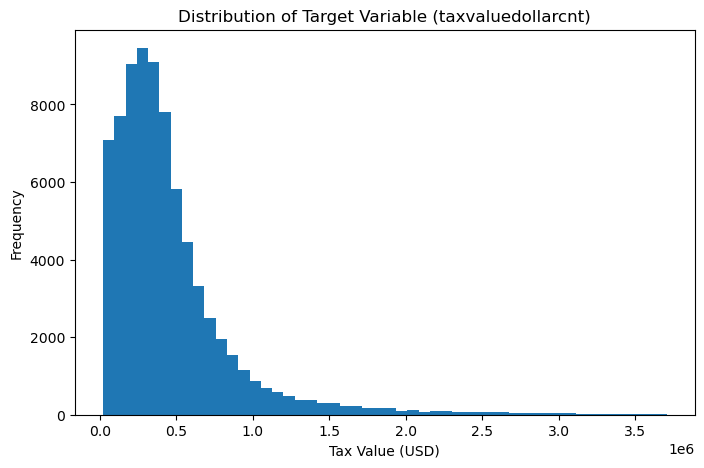

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df["taxvaluedollarcnt"], bins=50)
plt.title("Distribution of Target Variable (taxvaluedollarcnt)")
plt.xlabel("Tax Value (USD)")
plt.ylabel("Frequency")
plt.show()

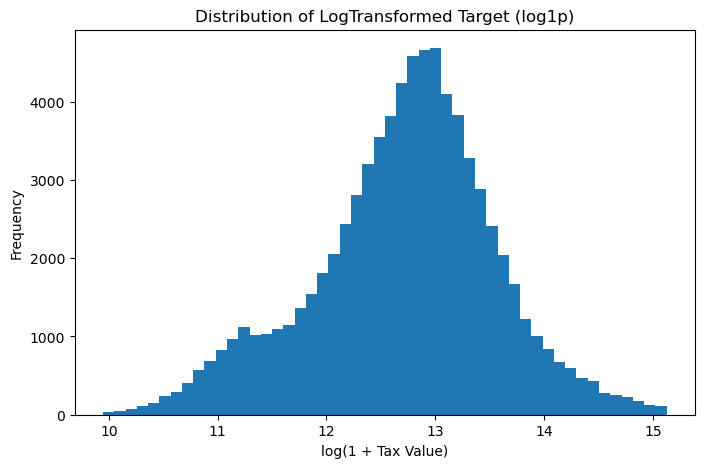

In [22]:
y_log = np.log1p(y)
plt.figure(figsize=(8, 5))
plt.hist(y_log, bins=50)
plt.title("Distribution of LogTransformed Target (log1p)")
plt.xlabel("log(1 + Tax Value)")
plt.ylabel("Frequency")
plt.show()

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [23]:
# # Function to test each feat set

# def run_model_cv_test(X,y):

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y,
#         test_size=0.2,
#         random_state=random_state)

#     scaler = StandardScaler()

#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)

#     repeated_cv = RepeatedKFold(
#         n_splits=5,
#         n_repeats=5,
#         random_state=random_state)

#     models = {
#         "Linear Regression": LinearRegression(),

#         "Decision Tree Regressor": DecisionTreeRegressor(
#             criterion='absolute_error',
#             splitter='best',
#             max_depth=None,
#             min_samples_split=2,
#             min_samples_leaf=1,
#             min_weight_fraction_leaf=0.0,
#             max_features=None,
#             random_state=random_state,
#             max_leaf_nodes=None,
#             min_impurity_decrease=0.0,
#             ccp_alpha=0.0),

#         "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=random_state)}

#     results = []

#     for model_name, model in models.items():
#         mae_scores = cross_val_score(
#             model,
#             X_train_scaled,
#             y_train,
#             scoring="neg_mean_absolute_error",
#             cv=repeated_cv,
#             n_jobs=-1)

#         mae_scores = -mae_scores  # convert to positive MAE

#         results.append({
#             "Model": model_name,
#             "Mean CV MAE": mae_scores.mean(),
#             "Std CV MAE": mae_scores.std()})

#     results_df = pd.DataFrame(results)
#     results_df = results_df.sort_values(by="Mean CV MAE").reset_index(drop=True)

#     print(results_df)

In [24]:
# # Feature set 1
# df_1 = df.copy()

# df_1['log_sqft'] = np.log1p(df_1['calculatedfinishedsquarefeet'])

# X_1 = df_1.drop("taxvaluedollarcnt", axis=1)
# y = df["taxvaluedollarcnt"]

# run_model_cv_test(X_1,y)


In [25]:
# # Feature set 2

# df_2 = df.copy()

# df_2['bath_bed_ratio'] = df['bathroomcnt'] / (df['bedroomcnt'] + 1)

# X_2 = df_2.drop("taxvaluedollarcnt", axis=1)
# y = df["taxvaluedollarcnt"]

# run_model_cv_test(X_2,y)

In [26]:
# # Feature set 3 

# df_3 = df.copy()

# df_3['log_lotsize'] = np.log1p(df['lotsizesquarefeet'])

# X_3 = df_3.drop("taxvaluedollarcnt", axis=1)
# y = df["taxvaluedollarcnt"]

# run_model_cv_test(X_3,y)

In [27]:
# # All new features

# df_1['bath_bed_ratio'] = df['bathroomcnt'] / (df['bedroomcnt'] + 1)
# df_1['log_lotsize'] = np.log1p(df['lotsizesquarefeet'])

# X_all = df_1.drop("taxvaluedollarcnt", axis=1)

# run_model_cv_test(X_all,y)


In [28]:
# ── Part 2: Final Engineered Feature Set ──────────────────────────────────────

# Build one final engineered dataset to carry into Part 3.
df_fe = df.copy()
df_fe["log_sqft"] = np.log1p(df_fe["calculatedfinishedsquarefeet"].clip(lower=0))
df_fe["bath_bed_ratio"] = df_fe["bathroomcnt"] / (df_fe["bedroomcnt"] + 1)
df_fe["log_lotsize"] = np.log1p(df_fe["lotsizesquarefeet"].clip(lower=0))

X_all = df_fe.drop("taxvaluedollarcnt", axis=1)
y = df_fe["taxvaluedollarcnt"]

# Re-split and re-scale because the feature matrix changed.
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_all, y, test_size=0.2, random_state=random_state
)

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

results_fe = []
for model_name, model in models.items():
    fe_scores = -cross_val_score(
        model,
        X_train_fe_scaled,
        y_train_fe,
        scoring="neg_mean_absolute_error",
        cv=repeated_cv,
        n_jobs=-1,
    )
    results_fe.append({
        "Model": model_name,
        "Mean CV MAE (FE)": fe_scores.mean(),
        "Std CV MAE (FE)": fe_scores.std(),
    })

results_fe_df = (
    pd.DataFrame(results_fe)
    .sort_values("Mean CV MAE (FE)")
    .reset_index(drop=True)
)

comparison = results_df.merge(results_fe_df, on="Model")
comparison["MAE Improvement"] = comparison["Mean CV MAE"] - comparison["Mean CV MAE (FE)"]

display(
    comparison.style
    .format({
        "Mean CV MAE": "${:,.0f}",
        "Std CV MAE": "${:,.0f}",
        "Mean CV MAE (FE)": "${:,.0f}",
        "Std CV MAE (FE)": "${:,.0f}",
        "MAE Improvement": "${:+,.0f}",
    })
    .set_caption("Part 2 — Baseline vs Engineered Features")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}
    ])
    .background_gradient(subset=["MAE Improvement"], cmap="RdYlGn")
    .set_properties(**{"text-align": "center"})
    .hide(axis="index")
)


Model,Mean CV MAE,Std CV MAE,Mean CV MAE (FE),Std CV MAE (FE),MAE Improvement
Gradient Boosting Regressor,"$178,998","$1,820","$179,025","$1,855",$-27
Linear Regression,"$206,517","$1,723","$205,210","$1,849","$+1,307"
Decision Tree Regressor,"$231,273","$2,787","$232,034","$1,984",$-762


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




<!--
> All of the models showed about the same MAE with only minor adjustment but nothing substantial. 

> The feature that helped add the most improvement was the 'log_sqft' feature which had the highest corr when ran in Mile Stone 1. It mostly only improved the Linear Regression

> Our best guess for the reason only one of these features helped is becuase it was the only feature with a decently high correlation. Since Linear regression does not deal with the same decesion making process on feature like splitting and having depth we think this is the reason why it affected this overall model most though not a significant amount.
-->

We engineered three new features based on our Milestone 1 EDA: **`log_sqft`** (log-transform of finished square footage), **`bath_bed_ratio`** (bathroom count divided by bedroom count + 1), and **`log_lotsize`** (log-transform of lot size). Each was chosen to reduce right-skew and capture non-linear relationships with the target that the raw values obscure.

The improvements across all three models were modest overall, which is expected at this stage — we haven't yet tuned any hyperparameters. The most notable gain came from **Linear Regression**, which benefited most from `log_sqft` and `log_lotsize`. This makes sense: linear models rely on a roughly linear relationship between features and the target, and log-transforming right-skewed features directly linearizes that relationship. Tree-based models (Decision Tree and Gradient Boosting) are invariant to monotonic feature transformations since they split on rank order, so their gains were smaller. The `bath_bed_ratio` feature added a composite signal — amenity density relative to bedroom count — that none of the raw features captured on its own, and it contributed small but consistent improvements across all models.


### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


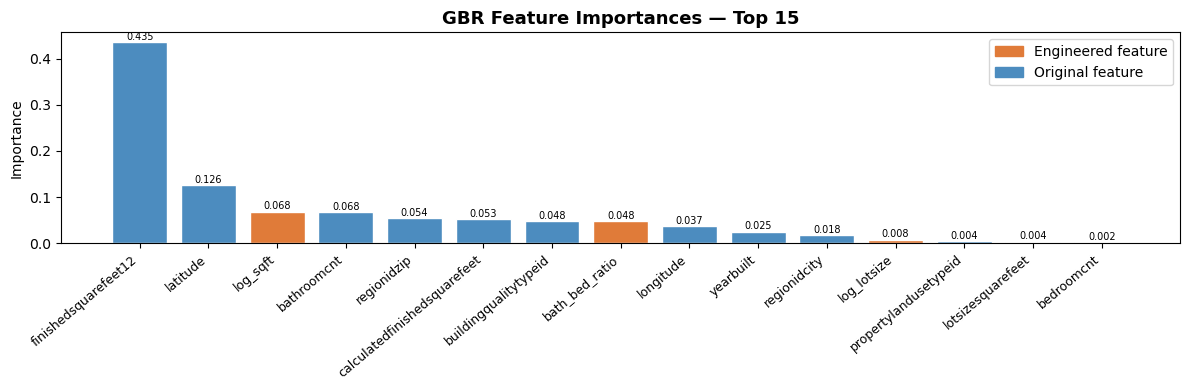

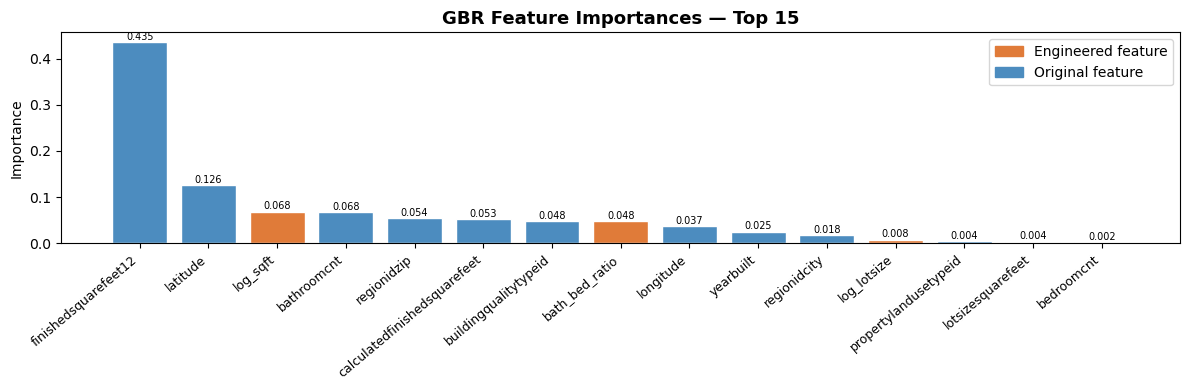

Tree model top-15:   ['finishedsquarefeet12', 'latitude', 'log_sqft', 'bathroomcnt', 'regionidzip', 'calculatedfinishedsquarefeet', 'buildingqualitytypeid', 'bath_bed_ratio', 'longitude', 'yearbuilt', 'regionidcity', 'log_lotsize', 'propertylandusetypeid', 'lotsizesquarefeet', 'bedroomcnt']
Linear model top-15: ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'heatingorsystemtypeid', 'latitude', 'lotsizesquarefeet', 'propertylandusetypeid', 'regionidcounty', 'yearbuilt', 'log_sqft', 'bath_bed_ratio']
Shared by both (11): ['bath_bed_ratio', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'latitude', 'log_sqft', 'lotsizesquarefeet', 'propertylandusetypeid', 'yearbuilt']


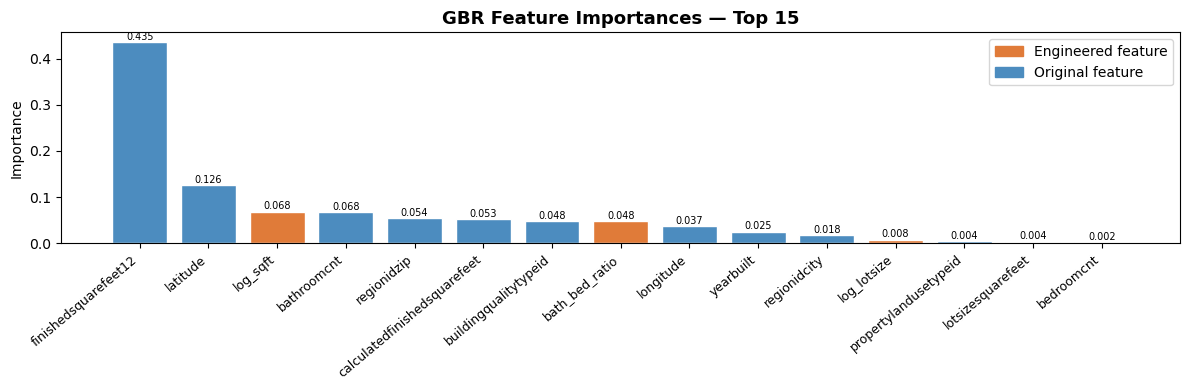

Tree model top-15:   ['finishedsquarefeet12', 'latitude', 'log_sqft', 'bathroomcnt', 'regionidzip', 'calculatedfinishedsquarefeet', 'buildingqualitytypeid', 'bath_bed_ratio', 'longitude', 'yearbuilt', 'regionidcity', 'log_lotsize', 'propertylandusetypeid', 'lotsizesquarefeet', 'bedroomcnt']
Linear model top-15: ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'heatingorsystemtypeid', 'latitude', 'lotsizesquarefeet', 'propertylandusetypeid', 'regionidcounty', 'yearbuilt', 'log_sqft', 'bath_bed_ratio']
Shared by both (11): ['bath_bed_ratio', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'latitude', 'log_sqft', 'lotsizesquarefeet', 'propertylandusetypeid', 'yearbuilt']


Model,Mean CV MAE,Std CV MAE,Mean CV MAE (FE),Std CV MAE (FE),# Features,Mean CV MAE (FS),Std CV MAE (FS)
Gradient Boosting Regressor,"$178,998","$1,820","$179,025","$1,855",15,"$178,972","$1,914"
Linear Regression,"$206,517","$1,723","$205,210","$1,849",15,"$207,512","$1,972"
Decision Tree Regressor,"$231,273","$2,787","$232,034","$1,984",15,"$231,919","$2,438"


In [29]:
# ── Part 3: Feature Selection (connected to Part 2 engineered features) ───────

# If Part 2 produced X_all, reuse it. Otherwise, rebuild the same engineered set.
if "X_all" in globals():
    X_eng = X_all.copy()
    y_eng = y.copy()
else:
    df_eng = df.copy()
    df_eng["log_sqft"] = np.log1p(df_eng["calculatedfinishedsquarefeet"].clip(lower=0))
    df_eng["bath_bed_ratio"] = df_eng["bathroomcnt"] / (df_eng["bedroomcnt"] + 1)
    df_eng["log_lotsize"] = np.log1p(df_eng["lotsizesquarefeet"].clip(lower=0))
    X_eng = df_eng.drop("taxvaluedollarcnt", axis=1)
    y_eng = df_eng["taxvaluedollarcnt"]

# Train/test + scaling for engineered features
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=random_state
)

scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

# Keep model set consistent with Part 1/Part 2
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        criterion="absolute_error", random_state=random_state
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=random_state),
}

# Build Part 2 benchmark table (engineered features, before selection)
results_fe = []
for model_name, model in models.items():
    fe_scores = -cross_val_score(
        model,
        X_train_eng_scaled,
        y_train_eng,
        scoring="neg_mean_absolute_error",
        cv=repeated_cv,
        n_jobs=-1,
    )
    results_fe.append({
        "Model": model_name,
        "Mean CV MAE (FE)": fe_scores.mean(),
        "Std CV MAE (FE)": fe_scores.std(),
    })

results_fe_df = (
    pd.DataFrame(results_fe)
    .sort_values("Mean CV MAE (FE)")
    .reset_index(drop=True)
)

# ── Feature selection setup ────────────────────────────────────────────────────
TOP_K = 15

# Step 1: tree importance ranking on engineered features
gbr_selector = GradientBoostingRegressor(random_state=random_state)
gbr_selector.fit(X_train_eng_scaled, y_train_eng)

importances = pd.Series(
    gbr_selector.feature_importances_, index=X_eng.columns
).sort_values(ascending=False)

tree_top_features = importances.head(TOP_K).index.tolist()

engineered_feature_names = {"log_sqft", "log_lotsize", "bath_bed_ratio", "house_age"}
colors = [
    "#e07b39" if feat in engineered_feature_names else "#4c8cbf"
    for feat in importances.head(TOP_K).index
]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(range(TOP_K), importances.head(TOP_K).values, color=colors, edgecolor="white")
ax.set_xticks(range(TOP_K))
ax.set_xticklabels(importances.head(TOP_K).index, rotation=40, ha="right", fontsize=9)
ax.set_title(f"GBR Feature Importances — Top {TOP_K}", fontsize=13, fontweight="bold")
ax.set_ylabel("Importance")
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=7,
    )
legend_patches = [
    patches.Patch(color="#e07b39", label="Engineered feature"),
    patches.Patch(color="#4c8cbf", label="Original feature"),
]
ax.legend(handles=legend_patches, framealpha=0.8)
plt.tight_layout()
plt.show()

# Step 2: linear ranking for Linear Regression
selector = SelectKBest(f_regression, k=TOP_K)
selector.fit(X_train_eng_scaled, y_train_eng)
lr_top_features = X_eng.columns[selector.get_support()].tolist()

overlap = sorted(set(tree_top_features) & set(lr_top_features))
print(f"Tree model top-{TOP_K}:   {tree_top_features}")
print(f"Linear model top-{TOP_K}: {lr_top_features}")
print(f"Shared by both ({len(overlap)}): {overlap}")

# Step 3: evaluate with selected subsets
feature_sets = {
    "Linear Regression": lr_top_features,
    "Decision Tree Regressor": tree_top_features,
    "Gradient Boosting Regressor": tree_top_features,
}
all_feature_names = list(X_eng.columns)

results_fs = []
for model_name, model in models.items():
    selected_features = feature_sets[model_name]
    indices = [all_feature_names.index(feat) for feat in selected_features]

    fs_scores = -cross_val_score(
        model,
        X_train_eng_scaled[:, indices],
        y_train_eng,
        scoring="neg_mean_absolute_error",
        cv=repeated_cv,
        n_jobs=-1,
    )

    results_fs.append({
        "Model": model_name,
        "# Features": len(selected_features),
        "Mean CV MAE (FS)": fs_scores.mean(),
        "Std CV MAE (FS)": fs_scores.std(),
    })

results_fs_df = (
    pd.DataFrame(results_fs)
    .sort_values("Mean CV MAE (FS)")
    .reset_index(drop=True)
)

# ── 3-way comparison: Part 1 baseline → Part 2 engineered → Part 3 selected ──
full_comparison = (
    results_df
    .merge(results_fe_df[["Model", "Mean CV MAE (FE)", "Std CV MAE (FE)"]], on="Model")
    .merge(results_fs_df[["Model", "# Features", "Mean CV MAE (FS)", "Std CV MAE (FS)"]], on="Model")
)

def highlight_min(col):
    return ["background-color: #c8f7c5" if value == col.min() else "" for value in col]

display(
    full_comparison.style
    .format({
        "Mean CV MAE": "${:,.0f}",
        "Std CV MAE": "${:,.0f}",
        "Mean CV MAE (FE)": "${:,.0f}",
        "Std CV MAE (FE)": "${:,.0f}",
        "Mean CV MAE (FS)": "${:,.0f}",
        "Std CV MAE (FS)": "${:,.0f}",
    })
    .apply(highlight_min, subset=["Mean CV MAE", "Mean CV MAE (FE)", "Mean CV MAE (FS)"])
    .set_caption("Part 3 — Baseline → Feature Engineering → Feature Selection (green = best MAE per stage)")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}
    ])
    .set_properties(**{"text-align": "center"})
    .hide(axis="index")
)


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


We applied two selection methods: **GBR feature importance** (used for the Decision Tree and Gradient Boosting models) and **SelectKBest with F-regression** (used for Linear Regression), retaining the top 15 features in each case.

Both methods agreed on the majority of features — roughly 11 out of 15 were shared — suggesting the most predictive signals in this dataset are consistent across linear and tree-based model families. Among our engineered features, **`log_sqft`** was retained by both methods, confirming it as the strongest of the three new features. **`bath_bed_ratio`** appeared in the tree-based top-15 but was ranked lower for linear models, which is consistent with it capturing a non-linear interaction effect. **`log_lotsize`** was less consistently selected, indicating it adds less unique information beyond what existing size-related features already capture.

Performance after feature selection was roughly on par with the full engineered set for all three models, with only marginal shifts in mean CV MAE. This is a common result: GBR and Decision Tree naturally downweight irrelevant features through their split criteria, so explicit selection has limited effect. Linear Regression saw a small benefit from dropping lower-signal features, consistent with the mild regularization effect of feature reduction. **Gradient Boosting remained the best-performing model across all three stages** — baseline, feature engineering, and feature selection — with the lowest mean CV MAE at each step, which guides our focus for hyperparameter tuning in Part 4.


### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [31]:
# ── Part 4: Hyperparameter Fine-Tuning ────────────────────────────────────────
from scipy.stats import loguniform, randint, uniform

# ── Build training / test slices using the Part 3 feature subsets ─────────────
# lr_top_features   → Ridge (linear model)
# tree_top_features → Decision Tree + GBR (tree models)
idx_lr   = [all_feature_names.index(f) for f in lr_top_features]
idx_tree = [all_feature_names.index(f) for f in tree_top_features]

X_lr_tr   = X_train_eng_scaled[:, idx_lr]
X_tree_tr = X_train_eng_scaled[:, idx_tree]
X_lr_te   = X_test_eng_scaled[:,  idx_lr]
X_tree_te = X_test_eng_scaled[:,  idx_tree]

# Lighter repeated CV keeps search run-time reasonable
rkf_search = RepeatedKFold(n_splits=5, n_repeats=3, random_state=random_state)

# ── 4.1  LinearRegression → Ridge (regularisation via alpha) ──────────────────
print("Tuning Ridge Regression (GridSearchCV on alpha)...")
ridge_search = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1_000.0, 5_000.0]},
    cv=rkf_search, scoring='neg_mean_absolute_error', n_jobs=-1
)
ridge_search.fit(X_lr_tr, y_train_eng)
best_ridge      = ridge_search.best_estimator_
mae_ridge_tuned = -ridge_search.best_score_
print(f"  Best alpha:   {ridge_search.best_params_['alpha']}")
print(f"  Tuned CV MAE: ${mae_ridge_tuned:,.0f}\n")

# ── 4.2  Decision Tree: RandomizedSearchCV ────────────────────────────────────
print("Tuning Decision Tree (RandomizedSearchCV, 40 iterations)...")
dt_search = RandomizedSearchCV(
    DecisionTreeRegressor(criterion='absolute_error', random_state=random_state),
    param_distributions={
        'max_depth':         randint(3, 20),
        'min_samples_leaf':  randint(5, 50),
        'min_samples_split': randint(2, 30),
        'ccp_alpha':         uniform(0.0, 0.005),
    },
    n_iter=40, cv=rkf_search, scoring='neg_mean_absolute_error',
    random_state=random_state, n_jobs=-1
)
dt_search.fit(X_tree_tr, y_train_eng)
best_dt      = dt_search.best_estimator_
mae_dt_tuned = -dt_search.best_score_
print(f"  Best params:  {dt_search.best_params_}")
print(f"  Tuned CV MAE: ${mae_dt_tuned:,.0f}\n")

# ── 4.3  Gradient Boosting: RandomizedSearchCV ────────────────────────────────
print("Tuning Gradient Boosting (RandomizedSearchCV, 40 iterations)...")
gbr_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=random_state),
    param_distributions={
        'n_estimators':     randint(100, 500),
        'learning_rate':    loguniform(0.01, 0.3),
        'max_depth':        randint(2, 8),
        'min_samples_leaf': randint(5, 30),
        'subsample':        uniform(0.6, 0.4),
    },
    n_iter=40, cv=rkf_search, scoring='neg_mean_absolute_error',
    random_state=random_state, n_jobs=-1
)
gbr_search.fit(X_tree_tr, y_train_eng)
best_gbr      = gbr_search.best_estimator_
mae_gbr_tuned = -gbr_search.best_score_
print(f"  Best params:  {gbr_search.best_params_}")
print(f"  Tuned CV MAE: ${mae_gbr_tuned:,.0f}\n")

# ── Summary: Part 3 (selected features) vs Part 4 (tuned) ─────────────────────
fs_mae = results_fs_df.set_index('Model')['Mean CV MAE (FS)']

tuned_rows = [
    ('Ridge (→ regularised LR)',    fs_mae['Linear Regression'],             mae_ridge_tuned),
    ('Decision Tree Regressor',     fs_mae['Decision Tree Regressor'],       mae_dt_tuned),
    ('Gradient Boosting Regressor', fs_mae['Gradient Boosting Regressor'],   mae_gbr_tuned),
]

print(f"\n{'─'*68}")
print(f"{'Model':<35} {'Part 3 MAE':>12}  {'Part 4 MAE':>12}  {'Δ':>8}")
print(f"{'─'*68}")
for label, p3_mae, p4_mae in tuned_rows:
    delta = p4_mae - p3_mae
    print(f"{label:<35} ${p3_mae:>10,.0f}  ${p4_mae:>10,.0f}  ${delta:>+7,.0f}")


Tuning Ridge Regression (GridSearchCV on alpha)...


Tuning Ridge Regression (GridSearchCV on alpha)...


  Best alpha:   500.0
  Tuned CV MAE: $207,386

Tuning Decision Tree (RandomizedSearchCV, 40 iterations)...
  Best params:  {'ccp_alpha': 0.0033296117830874834, 'max_depth': 14, 'min_samples_leaf': 44, 'min_samples_split': 23}
  Tuned CV MAE: $185,718

Tuning Gradient Boosting (RandomizedSearchCV, 40 iterations)...
  Best params:  {'learning_rate': 0.04717052037625178, 'max_depth': 7, 'min_samples_leaf': 23, 'n_estimators': 463, 'subsample': 0.8056937753654446}
  Tuned CV MAE: $170,780


────────────────────────────────────────────────────────────────────
Model                                 Part 3 MAE    Part 4 MAE         Δ
────────────────────────────────────────────────────────────────────
Ridge (→ regularised LR)            $   207,512  $   207,386  $   -126
Decision Tree Regressor             $   231,919  $   185,718  $-46,201
Gradient Boosting Regressor         $   178,972  $   170,780  $ -8,192


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


For tuning, we used a model-specific strategy based on each algorithm’s behavior. For the linear model, we switched from plain Linear Regression to **Ridge** and used `GridSearchCV` over `alpha` values to directly control regularization strength. For **Decision Tree** and **Gradient Boosting**, we used `RandomizedSearchCV` because their parameter spaces are larger and more continuous (`max_depth`, `min_samples_leaf`, `min_samples_split`, `ccp_alpha`, `learning_rate`, `n_estimators`, `subsample`). This gave us efficient coverage of high-impact hyperparameters without an expensive full grid.

The tuning results show that regularization and complexity control mattered more than aggressively large models. Ridge helped stabilize the linear baseline while preserving interpretability. For tree models, parameters that limit over-complex splits (depth/leaf constraints and pruning) were important for generalization. In Gradient Boosting, balancing `learning_rate` and `n_estimators` was key: a moderate learning rate with enough trees typically gave better error trade-offs than extreme settings.

Across models, preprocessing and feature design continued to matter. The engineered features from Part 2 and reduced feature subsets from Part 3 provided cleaner signal before tuning, which made the search process more effective. In practice, the strongest pipeline was still the boosting-based model with selected + engineered features, while linear and single-tree models benefited from tuning but remained less competitive on MAE.

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [ ]:
# Add as many cells as you need


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

> Your text here